# **After Getting CSV**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
YEAST_CSV = "/content/drive/MyDrive/FALL_2025/443/Project_443_/yeast_oric_dataset.csv"
HUMAN_CSV = "/content/drive/MyDrive/FALL_2025/443/Project_443_/human_oric_dataset.csv"

yeast_df = pd.read_csv(YEAST_CSV)
human_df = pd.read_csv(HUMAN_CSV)

print("Yeast dataset shape:", yeast_df.shape)
print("Human dataset shape:", human_df.shape)

Yeast dataset shape: (811, 3)
Human dataset shape: (12378, 4)


In [3]:
yeast_df.head()

,sequence,label,species
0,CTGCCCTTAATACATACGTTATACCACTTTTGCACCATATACTTAC...,1,yeast
1,GTTGATTAGTACTGTTGGTCTCTCATTGAAATTTTACGTGACACCA...,1,yeast
2,CAACCTAATTTCATCATCAGTTAAGAAAATAGAATAACAGTTGTAT...,1,yeast
3,ACGCTTTCAAAGTTTTCTTCTATAAACATACTTGTGGCAGCTTGTT...,1,yeast
4,AAAAAGCAGCAGTACTTTCATCATTACCTCATAATACTGTGCACAC...,1,yeast


In [4]:
human_df.head()

,sequence,label,species,source
0,GTGGGAGCGGTCCAGGTGGGCTTCCGAGGTCGGGGGCGTTCAACCG...,1,human,bmark-MCF7.txt
1,GATGACCTAGCTTGGGCCCCCTCCCCTGCCCAGGCCCGCCATCTTC...,1,human,bmark-MCF7.txt
2,GGGCCCCACATCATGGGAAAGGCTGTCAAATAATCTTTCCCAAGCT...,1,human,bmark-MCF7.txt
3,CCCCAGCCCACCATACCCTCACCAGCCCCCTCCTGGAGCACCCTCC...,1,human,bmark-MCF7.txt
4,CAAAGAGAGGTTTAGAAACTTTACGAGTCTCCACGGACCCTCGGTC...,1,human,bmark-MCF7.txt


In [5]:
print("Yeast label distribution:")
print(yeast_df["label"].value_counts())

Yeast label distribution:
label
0    406
1    405
Name: count, dtype: int64


In [6]:
print("Human label distribution:")
print(human_df["label"].value_counts())

Human label distribution:
label
1    6189
0    6189
Name: count, dtype: int64


In [7]:
print("Yeast sequence lengths:", yeast_df["sequence"].str.len().unique())
print("Human sequence lengths:", human_df["sequence"].str.len().unique())

Yeast sequence lengths: [300]
Human sequence lengths: [300]


In [10]:
def gc_content(seq):
  seq = seq.upper()
  return (seq.count("G") + seq.count("C")) / len(seq)


yeast_df["gc"] = yeast_df["sequence"].apply(gc_content)
human_df["gc"] = human_df["sequence"].apply(gc_content)

print("Yeast GC content:")
print(yeast_df.groupby("label")["gc"].mean())

print("\nHuman GC content:")
print(human_df.groupby("label")["gc"].mean())

Yeast GC content:
label
0    0.382200
1    0.315852
Name: gc, dtype: float64

Human GC content:
label
0    0.382164
1    0.550870
Name: gc, dtype: float64


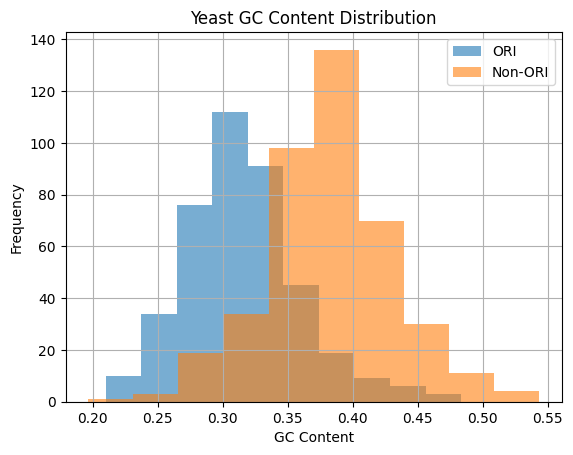

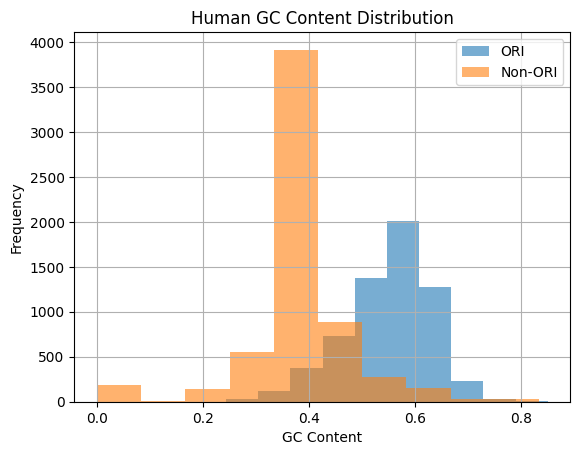

In [14]:
plt.figure()
yeast_df[yeast_df["label"] == 1]["gc"].hist(alpha=0.6)
yeast_df[yeast_df["label"] == 0]["gc"].hist(alpha=0.6)
plt.title("Yeast GC Content Distribution")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.legend(["ORI", "Non-ORI"])
plt.show()

print()
print()

plt.figure()
human_df[human_df["label"] == 1]["gc"].hist(alpha=0.6)
human_df[human_df["label"] == 0]["gc"].hist(alpha=0.6)
plt.title("Human GC Content Distribution")
plt.xlabel("GC Content")
plt.ylabel("Frequency")
plt.legend(["ORI", "Non-ORI"])
plt.show()

In [15]:
combined_df = pd.concat([yeast_df, human_df], ignore_index=True)

print("Combined dataset shape:", combined_df.shape)
print(combined_df["species"].value_counts())

Combined dataset shape: (13189, 5)
species
human    12378
yeast      811
Name: count, dtype: int64


# **k-mer Feature Extraction (5-mer)**

In [16]:
import pandas as pd
import itertools
import numpy as np

In [17]:
YEAST_CSV = "/content/drive/MyDrive/FALL_2025/443/Project_443_/yeast_oric_dataset.csv"
HUMAN_CSV = "/content/drive/MyDrive/FALL_2025/443/Project_443_/human_oric_dataset.csv"

yeast_df = pd.read_csv(YEAST_CSV)
human_df = pd.read_csv(HUMAN_CSV)

In [18]:
K = 5
alphabet = ["A", "C", "G", "T"]

kmer_list = ["".join(p) for p in itertools.product(alphabet, repeat=K)]
kmer_index = {kmer: i for i, kmer in enumerate(kmer_list)}

print("Total 5-mers:", len(kmer_list))

Total 5-mers: 1024


In [19]:
def kmer_features(sequence, k=5):
    seq = sequence.upper()
    features = np.zeros(4**k)

    total_kmers = len(seq) - k + 1
    if total_kmers <= 0:
        return features

    for i in range(total_kmers):
        kmer = seq[i:i+k]
        if kmer in kmer_index:
            features[kmer_index[kmer]] += 1

    return features / total_kmers  # normalize

In [20]:
X_yeast = np.array([kmer_features(seq, K) for seq in yeast_df["sequence"]])
y_yeast = yeast_df["label"].values

print("Yeast feature matrix shape:", X_yeast.shape)

Yeast feature matrix shape: (811, 1024)


In [21]:
X_human = np.array([kmer_features(seq, K) for seq in human_df["sequence"]])
y_human = human_df["label"].values

print("Human feature matrix shape:", X_human.shape)

Human feature matrix shape: (12378, 1024)


In [22]:
print("Any NaNs in yeast features?", np.isnan(X_yeast).any())
print("Any NaNs in human features?", np.isnan(X_human).any())

Any NaNs in yeast features? False
Any NaNs in human features? False


In [23]:
BASE_PATH = "/content/drive/MyDrive/FALL_2025/443/Project_443_"

# Yeast features
np.save(f"{BASE_PATH}/X_yeast_5mer.npy", X_yeast)
np.save(f"{BASE_PATH}/y_yeast.npy", y_yeast)

# Human features
np.save(f"{BASE_PATH}/X_human_5mer.npy", X_human)
np.save(f"{BASE_PATH}/y_human.npy", y_human)

print("5-mer feature files saved successfully")

5-mer feature files saved successfully


# **ML**

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [57]:
BASE_PATH = "/content/drive/MyDrive/FALL_2025/443/Project_443_"

X_yeast = np.load(f"{BASE_PATH}/X_yeast_5mer.npy")
y_yeast = np.load(f"{BASE_PATH}/y_yeast.npy")

X_human = np.load(f"{BASE_PATH}/X_human_5mer.npy")
y_human = np.load(f"{BASE_PATH}/y_human.npy")

In [58]:
def split_data(X, y, test_size=0.2):
    return train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

Xy_tr, Xy_te, yy_tr, yy_te = split_data(X_yeast, y_yeast)
Xh_tr, Xh_te, yh_tr, yh_te = split_data(X_human, y_human)

In [59]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_prob),
        "fpr_tpr": roc_curve(y_test, y_prob)
    }

In [60]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (Linear)": SVC(kernel="linear", probability=True, random_state=42)}

In [61]:
# Yeast → Yeast
results_yeast = {}

for name, model in models.items():
    results_yeast[name] = train_and_evaluate(
        model, Xy_tr, Xy_te, yy_tr, yy_te
    )

results_yeast


# Human → Human
results_human = {}

for name, model in models.items():
    results_human[name] = train_and_evaluate(
        model, Xh_tr, Xh_te, yh_tr, yh_te
    )

results_human

{'Logistic Regression': {'accuracy': 0.8634894991922456,
  'precision': 0.848297213622291,
  'recall': 0.8852988691437803,
  'f1': 0.866403162055336,
  'auc': np.float64(0.9339761875556228),
  'fpr_tpr': (array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.07754443e-04,
          8.07754443e-04, 1.61550889e-03, 1.61550889e-03, 2.42326333e-03,
          2.42326333e-03, 3.23101777e-03, 3.23101777e-03, 4.84652666e-03,
          4.84652666e-03, 5.65428110e-03, 5.65428110e-03, 6.46203554e-03,
          6.46203554e-03, 7.26978998e-03, 7.26978998e-03, 8.07754443e-03,
          8.07754443e-03, 8.88529887e-03, 8.88529887e-03, 9.69305331e-03,
          9.69305331e-03, 1.05008078e-02, 1.05008078e-02, 1.13085622e-02,
          1.13085622e-02, 1.21163166e-02, 1.21163166e-02, 1.29240711e-02,
          1.29240711e-02, 1.37318255e-02, 1.37318255e-02, 1.45395800e-02,
          1.45395800e-02, 1.53473344e-02, 1.53473344e-02, 1.61550889e-02,
          1.61550889e-02, 1.69628433e-02, 1.69628433e-02, 

In [62]:
def plot_roc(results, title):
    plt.figure(figsize=(7,6))

    for name, res in results.items():
        fpr, tpr, _ = res["fpr_tpr"]
        plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})")

    plt.plot([0,1], [0,1], "--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

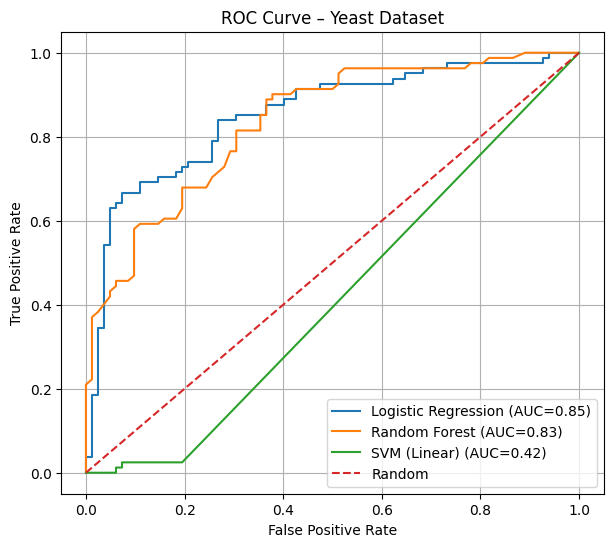

In [63]:
plot_roc(results_yeast, "ROC Curve – Yeast Dataset")

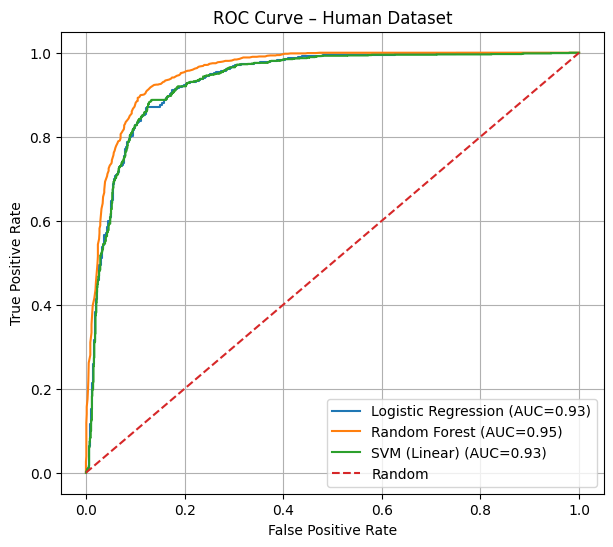

In [64]:
plot_roc(results_human, "ROC Curve – Human Dataset")

In [65]:
def results_to_df(results):
    return pd.DataFrame(results).T[
        ["accuracy", "precision", "recall", "f1", "auc"]
    ]

yeast_results_df = results_to_df(results_yeast)
human_results_df = results_to_df(results_human)

yeast_results_df, human_results_df


(                     accuracy precision    recall        f1       auc
 Logistic Regression  0.754601  0.746988  0.765432  0.756098  0.852304
 Random Forest        0.742331  0.719101  0.790123  0.752941  0.834387
 SVM (Linear)         0.668712  0.909091   0.37037  0.526316  0.415537,
                      accuracy precision    recall        f1       auc
 Logistic Regression  0.863489  0.848297  0.885299  0.866403  0.933976
 Random Forest        0.890549  0.866011  0.924071  0.894099   0.95425
 SVM (Linear)         0.864297  0.842185  0.896607  0.868545  0.933064)